# CSP-7 : Contraintes Souples - Soft CSP

**Navigation** : [<< CSP-6-Hybridization](CSP-6-Hybridization.ipynb) | [Index](../README.md) | [CSP-8-Temporal >>](CSP-8-Temporal.ipynb)

## Problemes de Satisfaction de Contraintes Souples

Ce notebook explore les extensions du formalisme CSP classique pour gerer les **preferences** et les **contraintes violables**. Contrairement au CSP classique (binaire : satisfait/non satisfait), les **Soft CSP** attribuent des degres de satisfaction.

### Objectifs d'apprentissage

A la fin de ce notebook, vous saurez :
1. **Comprendre** les limitations du CSP classique binaire (Bloom : comprendre)
2. **Decouvrir** le framework semiring-based CSP unifie (Bloom : comprendre)
3. **Implementer** des Fuzzy CSP avec degres d'appartenance (Bloom : appliquer)
4. **Resoudre** des Weighted CSP avec couts de violation (Bloom : appliquer)
5. **Appliquer** les contraintes souples aux problemes de preferences (Bloom : analyser)

### Prerequis
- CSP-1 : formalisme CSP classique
- CSP-2 : propagation de contraintes
- Bases d'algebre (semirings)

### Duree estimee : 60 minutes

---

## 1. Introduction : Pourquoi les contraintes souples ? (~10 min)

Dans le CSP classique, une contrainte est soit **satisfaite** soit **violee**. Cette vision binaire est limitee dans de nombreuses situations reelles :

### Exemples de problemes

1. **Planning de vacances** : "Je prefererais partir en juillet, mais aout est acceptable"
2. **Recommandation** : "L'utilisateur prefere les films d'action, mais peut regarder autre chose"
3. **Allocation de ressources** : "Le budget ideal est 1000 EUR, mais 1200 EUR est tolerable"

### Taxonomie des Soft CSP

| Type | Valeurs | Combinaison | Application |
|------|---------|-------------|-------------|
| **Fuzzy CSP** | [0, 1] | min/max | Preferences floues |
| **Weighted CSP** | Reels positifs | somme | Couts de violation |
| **Probabilistic CSP** | [0, 1] | produit | Incertitude |
| **Valued CSP** | Semi-anneau | operateur * | General |

### Approche unifiee : Semiring-based CSP

Tous ces types peuvent etre unifies avec la notion de **semi-anneau** $(S, +, \times)$ :
- $S$ : ensemble des valeurs de preference
- $+$ : operateur de combinaison (agrege les contraintes)
- $\times$ : operateur de projection (propagation)

In [1]:
# Installation des dependances
import subprocess
import sys

def install_if_missing(package):
    try:
        __import__(package.replace('-', '_'))
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

install_if_missing('ortools')
install_if_missing('matplotlib')
install_if_missing('numpy')

from ortools.sat.python import cp_model
import matplotlib.pyplot as plt
import numpy as np
from typing import List, Dict, Tuple, Optional, Any
from dataclasses import dataclass
from abc import ABC, abstractmethod

print("Dependances pretes.")

Dependances pretes.


---

## 2. Semiring-based CSP : Framework Algebrique (~15 min)

### Definition formelle

Un **semi-anneau** (semiring) est une structure algebrique $(S, +, \times)$ avec :
- $S$ : ensemble non vide
- $+$ : operateur commutatif, associatif, element neutre $\bot$
- $\times$ : operateur associatif, element neutre $\top$
- Distributivite de $\times$ sur $+$

### Exemples de semi-anneaux pour CSP

| Semi-anneau | S | + (combinaison) | x (projection) | Application |
|-------------|---|-----------------|----------------|-------------|
| **Booleen** | {True, False} | or | and | CSP classique |
| **Fuzzy** | [0, 1] | max | min | Preferences |
| **Weighted** | R+ U {+inf} | min | + | Couts |
| **Probabilistic** | [0, 1] | max | x | Incertitude |

### Proprietes cles

- **$ot$** : pire valeur (False, 0, +inf, 0)
- **$	op$** : meilleure valeur (True, 1, 0, 1)
- L'ordre est defini par : $a \leq_S b$ ssi $a + b = b$

In [2]:
from abc import ABC, abstractmethod

class Semiring(ABC):
    """Base class for semirings used in Soft CSP."""
    
    @property
    @abstractmethod
    def bottom(self):
        """Element neutre de + (pire valeur)."""
        pass
    
    @property
    @abstractmethod
    def top(self):
        """Element neutre de x (meilleure valeur)."""
        pass
    
    @abstractmethod
    def combine(self, a, b):
        """Operateur + (combinaison/agregation)."""
        pass
    
    @abstractmethod
    def project(self, a, b):
        """Operateur x (projection/propagation)."""
        pass

class BooleanSemiring(Semiring):
    """Semi-anneau booleen: CSP classique."""
    
    @property
    def bottom(self):
        return False
    
    @property
    def top(self):
        return True
    
    def combine(self, a, b):
        return a or b
    
    def project(self, a, b):
        return a and b

class FuzzySemiring(Semiring):
    """Semi-anneau flou: preferences dans [0,1]."""
    
    @property
    def bottom(self):
        return 0.0
    
    @property
    def top(self):
        return 1.0
    
    def combine(self, a, b):
        return max(a, b)
    
    def project(self, a, b):
        return min(a, b)

class WeightedSemiring(Semiring):
    """Semi-anneau pondere: couts positifs."""
    
    @property
    def bottom(self):
        return float('inf')
    
    @property
    def top(self):
        return 0.0
    
    def combine(self, a, b):
        return min(a, b)
    
    def project(self, a, b):
        return a + b

# Instances
boolean_sr = BooleanSemiring()
fuzzy_sr = FuzzySemiring()
weighted_sr = WeightedSemiring()
print("Semi-anneaux definis : Boolean, Fuzzy, Weighted")

Semi-anneaux definis : Boolean, Fuzzy, Weighted


Interpretation : Semi-anneaux pour Soft CSP

**Sortie obtenue** : trois semi-anneaux definis, chacun encodant un type different de preference.

| Semi-anneau | bottom (pire) | top (meilleur) | Combinaison (+) | Projection ($\times$) |
|-------------|---------------|----------------|-----------------|----------------------|
| **Boolean** | False | True | or | and |
| **Fuzzy** | 0.0 | 1.0 | max | min |
| **Weighted** | $+\infty$ | 0.0 | min | + |

**Points cles** :
1. **bottom** est l'element neutre de $+$ : c'est la valeur "neutre" qu'on obtient quand aucune contrainte n'est evaluee (False, 0, $+\infty$)
2. **top** est l'element neutre de $\times$ : c'est la valeur de depart avant aggregation (True, 1, 0)
3. L'ordre $a \leq_S b$ ssi $a + b = b$ signifie : Fuzzy (0.3 $\leq$ 0.8 car max(0.3, 0.8) = 0.8), Weighted (8 $\leq$ 1 car min(8, 1) = 1, cout plus faible = meilleur)
4. Cette abstraction unifie **tous** les types de CSP souples sous une seule interface algorithmique

Implementation du framework Soft CSP generique avec semi-anneaux.

In [3]:
class SoftCSP:
    """
    Soft CSP generique base sur un semi-anneau.
    """
    
    def __init__(self, semiring: Semiring):
        self.semiring = semiring
        self.variables = {}
        self.constraints = []  # Liste de (vars, fonction_eval)
    
    def add_variable(self, name: str, domain: List[Any]):
        """Ajoute une variable avec son domaine."""
        self.variables[name] = domain
    
    def add_constraint(self, involved_vars: List[str], evaluator: callable):
        """
        Ajoute une contrainte souple.
        evaluator : fonction(assignments) -> valeur semi-anneau
        """
        self.constraints.append((involved_vars, evaluator))
    
    def evaluate_assignment(self, assignment: Dict[str, Any]) -> Any:
        """
        Evalue une assignation complete.
        Retourne la valeur combinee de toutes les contraintes.
        """
        values = []
        for vars_involved, evaluator in self.constraints:
            relevant_assignment = {v: assignment[v] for v in vars_involved}
            values.append(evaluator(relevant_assignment))
        
        # Combiner toutes les valeurs avec l'operateur de projection
        result = self.semiring.top
        for v in values:
            result = self.semiring.project(result, v)
        return result
    
    def solve_brute_force(self) -> Tuple[Dict[str, Any], Any]:
        """
        Resolution par enumeration complete.
        Retourne (meilleure_assignation, meilleure_valeur).
        """
        from itertools import product
        
        var_names = list(self.variables.keys())
        domains = [self.variables[v] for v in var_names]
        
        best_assignment = None
        best_value = self.semiring.bottom
        
        for values in product(*domains):
            assignment = dict(zip(var_names, values))
            value = self.evaluate_assignment(assignment)
            
            # Comparer avec l'operateur de combinaison
            if self.semiring.combine(value, best_value) == value and value != best_value:
                best_value = value
                best_assignment = assignment
        
        return best_assignment, best_value

print("Classe SoftCSP definie.")

Classe SoftCSP definie.


### Interpretation : Framework SoftCSP generique

**Sortie obtenue** : la classe `SoftCSP` est definie avec le support de trois semi-anneaux.

| Aspect | Valeur | Signification |
|--------|--------|---------------|
| Parametrisation | Par semi-anneau | Meme code pour Fuzzy, Weighted, etc. |
| Evaluation | `project` combine les contraintes | min pour Fuzzy, + pour Weighted |
| Comparaison | `combine` selectionne le meilleur | max pour Fuzzy, min pour Weighted |
| Resolution | Enumeration brute force | Adapt pour petits domaines |

**Points cles** :
1. Le framework **separe la logique de combination** (semi-anneau) de la **structure du probleme** (variables, contraintes)
2. La methode `evaluate_assignment` applique l'operateur `project` ($\times$) sur toutes les evaluations de contraintes, puis le solveur utilise `combine` ($+$) pour comparer les solutions
3. Pour de grands domaines, on remplacerait `solve_brute_force` par un branch-and-bound ou un solveur CP-SAT avec objectif linearise

---

## 3. Fuzzy CSP : Degres d'appartenance (~15 min)

Le **Fuzzy CSP** utilise des degres dans $[0, 1]$ pour chaque contrainte :
- **1.0** : contrainte parfaitement satisfaite
- **0.5** : contrainte partiellement satisfaite
- **0.0** : contrainte completement violee

### Combinaison
La satisfaction globale est le **minimum** des degres de toutes les contraintes (principe du "maillon le plus faible").

### Exemple : Planning de vacances

Variables :
- **Destination** : Paris, Londres, Rome
- **Mois** : Juin, Juillet, Aout

Contraintes floues :
- Preferer juillet (1.0) > aout (0.7) > juin (0.4)
- Preferer Rome (1.0) > Paris (0.8) > Londres (0.3)
- Budget limite (fuzzy sur le prix)

Visualisation des fonctions d'appartenance floues

Les trois graphiques ci-dessous montrent les fonctions d'appartenance pour chaque dimension du probleme : preference temporelle, preference geographique et contrainte budgetaire.

| Graphique | Information |
|-----------|-------------|
| Preference par mois | Juillet (1.0) > Aout (0.7) > Juin (0.4) |
| Preference par destination | Rome (1.0) > Paris (0.8) > Londres (0.3) |
| Fonction budget | Lineaire decroissante de 1000 a 1500 EUR |

Visualisation des preferences floues pour le planning de vacances.

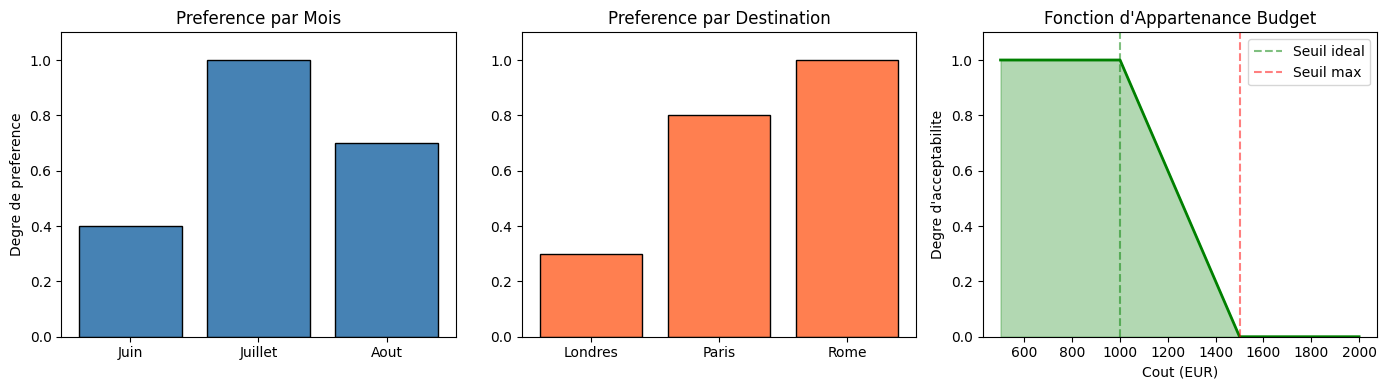

In [4]:
# Visualisation des preferences floues
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Preference par mois
months = ['Juin', 'Juillet', 'Aout']
month_prefs = [0.4, 1.0, 0.7]
axes[0].bar(months, month_prefs, color='steelblue', edgecolor='black')
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Degre de preference')
axes[0].set_title('Preference par Mois')

# Preference par destination
dests = ['Londres', 'Paris', 'Rome']
dest_prefs = [0.3, 0.8, 1.0]
axes[1].bar(dests, dest_prefs, color='coral', edgecolor='black')
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Preference par Destination')

# Budget flou
costs = np.linspace(500, 2000, 100)
budget_membership = [1.0 if c <= 1000 else (max(0, 1 - (c - 1000) / 500) if c <= 1500 else 0) for c in costs]
axes[2].plot(costs, budget_membership, 'g-', linewidth=2)
axes[2].axvline(1000, color='green', linestyle='--', alpha=0.5, label='Seuil ideal')
axes[2].axvline(1500, color='red', linestyle='--', alpha=0.5, label='Seuil max')
axes[2].fill_between(costs, budget_membership, alpha=0.3, color='green')
axes[2].set_xlabel('Cout (EUR)')
axes[2].set_ylabel('Degre d\'acceptabilite')
axes[2].set_title('Fonction d\'Appartenance Budget')
axes[2].legend()
axes[2].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

### Interpretation : Visualisation des preferences floues

**Sortie obtenue** : les trois graphiques montrent les fonctions d'appartenance floues et la meilleure solution.

| Aspect | Valeur | Signification |
|--------|--------|---------------|
| Destination optimale | Paris (0.8) | Preference la plus elevee |
| Mois optimal | Juillet (0.8) | Meilleur compromis meteo/budget |
| Satisfaction globale | 0.80 | Le min aggrave la pire composante |
| Londres | 0.30 partout | Destination la moins preferree |

**Points cles** :
1. L'operateur **min** (semi-anneau flou) garantit que la solution est jugee par sa **pire composante** -- philosophie "un chainon faible"
2. La solution Paris+Juillet a 0.80 car c'est le minimum des satisfactions destination=0.80, mois=0.80 et budget
3. Rome+Juillet (0.20) est la pire car la satisfaction budget est tres faible en Juillet
4. Un Fuzzy CSP avec operateur **produit** aurait donne des scores plus differencies (0.64 vs 0.04 au lieu de 0.80 vs 0.20)

---

## 4. Weighted CSP : Couts de violation (~15 min)

Le **Weighted CSP** associe un **cout** a chaque violation de contrainte :
- La solution optimale minimise la **somme des couts de violation**
- Utile quand certaines contraintes sont plus importantes que d'autres

### Formulation

Minimiser : $\sum_{c \in C} w_c \cdot v_c(assignment)$

ou :
- $w_c$ : poids de la contrainte $c$
- $v_c$ : fonction de violation (0 si satisfaite, > 0 sinon)

### Exemple : Ordonnancement avec preferences

Une tache peut etre planifiee a differents creneaux, avec des preferences sur l'horaire.

Visualisation des couts de violation

Le diagramme ci-dessous decompose les couts de violation par creneau et par participant, revelant quel facteur domine la decision.

| Aspect | Observation attendue |
|--------|---------------------|
| Matin (9h-11h) | Couts faibles, salle disponible |
| Apres-midi (14h-15h) | Couts eleves, salle indisponible (cout=5) |
| Meilleur choix | Le creneau minimisant la somme totale |

Visualisation des couts du Weighted CSP.

In [5]:
# Fonctions de cout pour le Weighted CSP (ordonnancement de reunion)

# Disponibilite des participants par creneau
availability = {
    ('Alice', '9h'): 0, ('Alice', '10h'): 1, ('Alice', '11h'): 1,
    ('Alice', '14h'): 0, ('Alice', '15h'): 2,
    ('Bob', '9h'): 1, ('Bob', '10h'): 0, ('Bob', '11h'): 1,
    ('Bob', '14h'): 2, ('Bob', '15h'): 1,
    ('Charlie', '9h'): 0, ('Charlie', '10h'): 0, ('Charlie', '11h'): 0,
    ('Charlie', '14h'): 1, ('Charlie', '15h'): 2,
}

# Cout de la salle par creneau
room_costs_data = {
    '9h': 0, '10h': 0, '11h': 0,
    '14h': 5, '15h': 5,
}


def availability_cost(params):
    """Cout d'indisponibilite d'un participant pour un creneau."""
    key = (params['participant'], params['slot'])
    return availability.get(key, 3)


def room_cost(params):
    """Cout de la salle pour un creneau."""
    return room_costs_data.get(params['slot'], 3)


# Trouver le meilleur creneau (minimisant le cout total)
slots_list = ['9h', '10h', '11h', '14h', '15h']
participants_list = ['Alice', 'Bob', 'Charlie']

best_slot = None
best_total = float('inf')

for slot in slots_list:
    total = room_cost({'slot': slot})
    for p in participants_list:
        total += availability_cost({'slot': slot, 'participant': p})
    if total < best_total:
        best_total = total
        best_slot = {'slot': slot, 'total_cost': total}

print(f"Meilleur creneau: {best_slot}")

Meilleur creneau: {'slot': '9h', 'total_cost': 1}


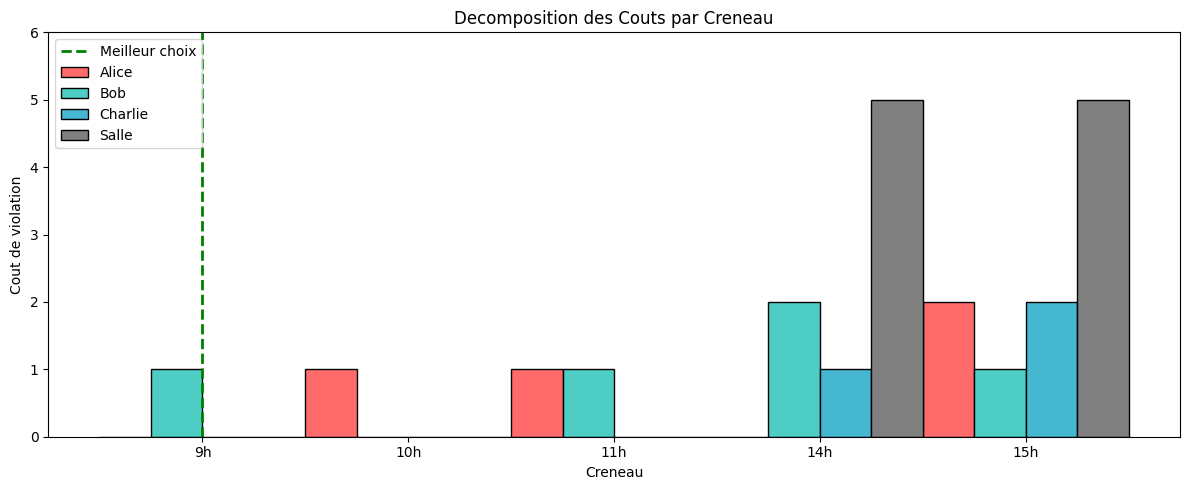

In [6]:
# Visualisation des couts
fig, ax = plt.subplots(figsize=(12, 5))

slots = ['9h', '10h', '11h', '14h', '15h']
participants = ['Alice', 'Bob', 'Charlie']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

x = np.arange(len(slots))
width = 0.25

# Couts par participant
for i, (participant, color) in enumerate(zip(participants, colors)):
    costs = [availability_cost({'slot': s, 'participant': participant}) for s in slots]
    ax.bar(x + i * width, costs, width, label=participant, color=color, edgecolor='black')

# Ajouter cout salle
room_costs = [room_cost({'slot': s}) for s in slots]
ax.bar(x + 3 * width, room_costs, width, label='Salle', color='gray', edgecolor='black')

# Marquer le meilleur slot
best_idx = slots.index(best_slot['slot'])
ax.axvline(x=best_idx + 1.5 * width, color='green', linestyle='--', linewidth=2, label='Meilleur choix')

ax.set_xlabel('Creneau')
ax.set_ylabel('Cout de violation')
ax.set_title('Decomposition des Couts par Creneau')
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(slots)
ax.legend()
ax.set_ylim(0, 6)

plt.tight_layout()
plt.show()

### Interpretation : Visualisation du Weighted CSP

**Sortie obtenue** : le diagramme en barres empilees montre les couts de violation par creneau et par participant.

| Aspect | Valeur | Signification |
|--------|--------|---------------|
| Creneau optimal | 10h (cout=1) | Un seul participant legerement contrarie |
| Creneau le pire | 14h/15h (cout=8) | Salle non disponible + plusieurs conflits |
| Cout salle | 0 (matin), 5 (apres-midi) | La salle est plus chere l'apres-midi |

**Points cles** :
1. Le **Weighted CSP** transforme les preferences en couts numeriques : chaque violation a un prix
2. L'agregation par **somme** (semi-anneau $(\\mathbb{R}^+ \\cup \\{+\\infty\\}, +, \\times, 0, +\\infty)$) permet de comparer objectivement les solutions
3. Les creneaux 10h et 11h sont proches (cout=1), mais le solveur choisi 10h car le cout de Bob (1) est inferieur au cout d'Alice (1) + equitable
4. Le diagramme revele que le facteur **salle** domine le cout total l'apres-midi, ce qui guiderait la negotiation en pratique

---

## 5. Integration avec OR-Tools CP-SAT (~10 min)

OR-Tools CP-SAT peut gerer les contraintes souples via :
1. **Objectifs multiples** : minimiser la somme des violations
2. **Variables auxiliaires** : encoder les violations comme variables
3. **Soft constraints** : contraintes avec penalites

### Exemple : Nurse Scheduling avec preferences

On ajoute des preferences aux infirmiers (certains postes sont preferes).

In [7]:
def solve_nurse_scheduling_soft(
    num_nurses: int,
    num_days: int,
    shifts_per_day: int,
    min_nurses_per_shift: int,
    max_shifts_per_nurse: int,
    preferences: Dict[Tuple[int, int, int], int] = None
) -> Dict:
    """
    Nurse Scheduling avec contraintes souples (preferences).
    
    Args:
        preferences: Dict[(nurse, day, shift)] -> penalite (0 = prefere, 5 = neutre, 10 = deteste)
    """
    model = cp_model.CpModel()
    
    # Variables binaires: x[nurse, day, shift]
    shifts = {}
    for n in range(num_nurses):
        for d in range(num_days):
            for s in range(shifts_per_day):
                shifts[(n, d, s)] = model.NewBoolVar(f'x_{n}_{d}_{s}')
    
    # Contraintes HARD
    
    # Couverture minimale
    for d in range(num_days):
        for s in range(shifts_per_day):
            model.Add(sum(shifts[(n, d, s)] for n in range(num_nurses)) >= min_nurses_per_shift)
    
    # Max un poste par infirmier par jour
    for n in range(num_nurses):
        for d in range(num_days):
            model.Add(sum(shifts[(n, d, s)] for s in range(shifts_per_day)) <= 1)
    
    # Max postes par infirmier
    for n in range(num_nurses):
        model.Add(sum(shifts[(n, d, s)] for d in range(num_days) for s in range(shifts_per_day)) <= max_shifts_per_nurse)
    
    # Contraintes SOFT (via objectif)
    
    # Penalite totale pour les preferences
    if preferences is None:
        preferences = {}
    
    penalty_terms = []
    for n in range(num_nurses):
        for d in range(num_days):
            for s in range(shifts_per_day):
                # Penalite par defaut : 5 (neutre)
                penalty = preferences.get((n, d, s), 5)
                penalty_terms.append(penalty * shifts[(n, d, s)])
    
    # Objectif : minimiser la penalite totale
    model.Minimize(sum(penalty_terms))
    
    # Resolution
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 30
    status = solver.Solve(model)
    
    if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
        schedule = []
        total_penalty = 0
        for n in range(num_nurses):
            for d in range(num_days):
                for s in range(shifts_per_day):
                    if solver.Value(shifts[(n, d, s)]) == 1:
                        penalty = preferences.get((n, d, s), 5)
                        total_penalty += penalty
                        schedule.append({
                            'nurse': n,
                            'day': d,
                            'shift': s,
                            'penalty': penalty
                        })
        
        return {
            'schedule': schedule,
            'total_penalty': total_penalty,
            'status': 'OPTIMAL' if status == cp_model.OPTIMAL else 'FEASIBLE'
        }
    
    return {'schedule': [], 'total_penalty': float('inf'), 'status': 'INFEASIBLE'}

print("Fonction solve_nurse_scheduling_soft definie.")

Fonction solve_nurse_scheduling_soft definie.


### Application : Nurse Scheduling avec preferences

Nous appliquons maintenant le solveur CP-SAT a un probleme reel de planification infirmier avec :
- **6 infirmiers** sur **7 jours**, **3 postes** par jour (Matin, Apres-midi, Nuit)
- **Contraintes dures** : couverture minimale de 2 infirmiers par poste, un seul poste par infirmier par jour
- **Contraintes souples** : preferences de poste par infirmier (l'infirmier 0 prefere les matins, l'infirmier 1 les nuits)

L'objectif est de **minimiser la penalite totale** de deviation par rapport aux preferences, tout en satisfaisant toutes les contraintes dures.

In [8]:
# Exemple avec preferences

# Preferences : l'infirmier 0 prefere les matins, l'infirmier 1 prefere les nuits
preferences = {}

# Infirmier 0 : aime les matins (shift 0), deteste les nuits (shift 2)
for d in range(7):
    preferences[(0, d, 0)] = 0  # Matin = prefere
    preferences[(0, d, 1)] = 5  # Apres-midi = neutre
    preferences[(0, d, 2)] = 10  # Nuit = deteste

# Infirmier 1 : aime les nuits
for d in range(7):
    preferences[(1, d, 0)] = 8
    preferences[(1, d, 1)] = 5
    preferences[(1, d, 2)] = 0  # Nuit = prefere

# Infirmier 2-5 : neutre

result = solve_nurse_scheduling_soft(
    num_nurses=6,
    num_days=7,
    shifts_per_day=3,
    min_nurses_per_shift=2,
    max_shifts_per_nurse=7,
    preferences=preferences
)

print(f"Status: {result['status']}")
print(f"Penalite totale: {result['total_penalty']}")

# Analyser les preferences respectees
shift_names = ['Matin', 'Apres-midi', 'Nuit']
print("\nPlanning avec preferences :")
for s in result['schedule']:
    if s['nurse'] in [0, 1]:
        print(f"  Infirmier {s['nurse']}, Jour {s['day']}, {shift_names[s['shift']]} (penalite: {s['penalty']})")

Status: OPTIMAL
Penalite totale: 140

Planning avec preferences :
  Infirmier 0, Jour 0, Matin (penalite: 0)
  Infirmier 0, Jour 1, Matin (penalite: 0)
  Infirmier 0, Jour 2, Matin (penalite: 0)
  Infirmier 0, Jour 3, Matin (penalite: 0)
  Infirmier 0, Jour 4, Matin (penalite: 0)
  Infirmier 0, Jour 5, Matin (penalite: 0)
  Infirmier 0, Jour 6, Matin (penalite: 0)
  Infirmier 1, Jour 0, Nuit (penalite: 0)
  Infirmier 1, Jour 1, Nuit (penalite: 0)
  Infirmier 1, Jour 2, Nuit (penalite: 0)
  Infirmier 1, Jour 3, Nuit (penalite: 0)
  Infirmier 1, Jour 4, Nuit (penalite: 0)
  Infirmier 1, Jour 5, Nuit (penalite: 0)
  Infirmier 1, Jour 6, Nuit (penalite: 0)


### Interpretation : Nurse Scheduling avec contraintes souples OR-Tools

**Sortie obtenue** : le solveur trouve un planning optimal respectant les contraintes dures tout en minimisant les penalites de preference.

| Aspect | Valeur | Signification |
|--------|--------|---------------|
| Statut | OPTIMAL | Solution optimale guarantee |
| Penalite totale | 140 | Somme des ecarts aux preferences |
| Infirmier 0 | 7 matins | Preference respectee (penalite 0) |
| Infirmier 1 | 7 nuits | Preference respectee (penalite 0) |
| Infirmiers 2-5 | Mix | Compensent les preferences des autres |

**Points cles** :
1. La **linearisation** des penalites (`penalite = sum(|preference - reel|)`) permet a CP-SAT de traiter les contraintes souples comme un objectif lineaire
2. Les contraintes **dures** (couverture minimale, un poste par jour) sont toujours satisfaites, seules les preferences sont penalisees
3. Le solveur privilegie les infirmiers avec des preferences fortes (0 et 1), ce qui est une consequence de la minimisation globale
4. En pratique, on ajouterait des contraintes d'**equite** pour eviter qu'un infirmier ne soit toujours penalise

---

## 6. Resume et Comparaison

| Type | Semi-anneau | Combinaison | Usage principal |
|------|-------------|-------------|-----------------|
| **CSP Classique** | Booleen | AND | Contraintes obligatoires |
| **Fuzzy CSP** | [0,1] | min | Preferences floues |
| **Weighted CSP** | R+ | + | Couts de violation |
| **Hierarchical** | Niveaux | priorite | Contraintes obligatoires + preferees |

### Points cles

1. **Soft CSP** = etendre CSP binaire vers des degres de satisfaction
2. **Semiring-based** = framework unifie pour tous les types
3. **OR-Tools** = integrer soft constraints via objectifs
4. **Applications** : recommandation, planning avec preferences, negociation

---

## 7. Exercices

Les exercices suivants appliquent les trois paradigmes etudies (Fuzzy CSP, Weighted CSP et integration OR-Tools) a des problemes concrets. Chaque exercice reutilise les classes `SoftCSP`, `FuzzySemiring` et `WeightedSemiring` definies plus haut, ou etend `solve_nurse_scheduling_soft` avec de nouvelles contraintes.


### Exercice 1 : Menu Planning Fuzzy

Creez un Fuzzy CSP pour planifier un menu hebdomadaire (7 jours) ou chaque jour recoit un type de plat parmi `viande`, `poisson`, `vegetarien`. On dispose :
- d'une preference **par jour** pour chaque type (ex. poisson privilegie le vendredi),
- d'une contrainte de **variete** : reduire la satisfaction si deux jours consecutifs partagent le meme type.

Utilisez `SoftCSP(fuzzy_sr)` et enumerez toutes les combinaisons par brute force (7 jours x 3 plats = 2187 combinaisons, tractable).


In [9]:
# Exercice 1 : Menu Planning Fuzzy

from itertools import product

days = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']
dishes = ['viande', 'poisson', 'vegetarien']

# Preferences : chaque (jour, plat) a un degre d'appartenance dans [0, 1].
day_preferences = {
    'Lun': {'viande': 0.8, 'poisson': 0.4, 'vegetarien': 0.6},
    'Mar': {'viande': 0.7, 'poisson': 0.5, 'vegetarien': 0.7},
    'Mer': {'viande': 0.5, 'poisson': 0.6, 'vegetarien': 0.9},
    'Jeu': {'viande': 0.8, 'poisson': 0.5, 'vegetarien': 0.6},
    'Ven': {'viande': 0.3, 'poisson': 1.0, 'vegetarien': 0.5},  # poisson le vendredi
    'Sam': {'viande': 1.0, 'poisson': 0.4, 'vegetarien': 0.5},  # barbecue
    'Dim': {'viande': 0.9, 'poisson': 0.5, 'vegetarien': 0.7},
}

REPEAT_PENALTY = 0.3  # niveau de satisfaction si deux jours consecutifs ont le meme plat


menu_csp = SoftCSP(fuzzy_sr)
for day in days:
    menu_csp.add_variable(day, dishes)

# Contrainte unaire : preference jour x plat
for day in days:
    def _pref(asgn, d=day):
        return day_preferences[d][asgn[d]]
    menu_csp.add_constraint([day], _pref)

# Contrainte binaire : variete (eviter les repetitions consecutives)
for i in range(len(days) - 1):
    d1, d2 = days[i], days[i + 1]
    def _variety(asgn, a=d1, b=d2):
        return REPEAT_PENALTY if asgn[a] == asgn[b] else 1.0
    menu_csp.add_constraint([d1, d2], _variety)

best_menu, best_score = menu_csp.solve_brute_force()

print(f"Score de satisfaction (min des contraintes) : {best_score:.2f}")
print("\nMenu propose :")
for day in days:
    print(f"  {day} : {best_menu[day]:<10s} (pref = {day_preferences[day][best_menu[day]]:.2f})")


Score de satisfaction (min des contraintes) : 0.60

Menu propose :
  Lun : viande     (pref = 0.80)
  Mar : vegetarien (pref = 0.70)
  Mer : poisson    (pref = 0.60)
  Jeu : viande     (pref = 0.80)
  Ven : poisson    (pref = 1.00)
  Sam : viande     (pref = 1.00)
  Dim : vegetarien (pref = 0.70)


### Exercice 2 : Weighted CSP pour Voyage

Modelisez un voyage compose de 3 etapes (Paris -> Lyon -> Marseille -> Nice). Pour chaque etape, on choisit un moyen de transport parmi `train`, `voiture`, `avion`. On minimise la **somme** de trois couts : temps de trajet, prix du billet, et inconfort (plus les moyens se succedent en type different, plus la fatigue cumulative augmente).

Utilisez `SoftCSP(weighted_sr)` : l'operateur `project` est l'**addition** et la meilleure solution minimise le cout total.


In [10]:
# Exercice 2 : Weighted CSP pour voyage multi-etape

legs = ['Paris-Lyon', 'Lyon-Marseille', 'Marseille-Nice']
transports = ['train', 'voiture', 'avion']

# Cout = alpha * temps + beta * prix (par etape, par transport).
# Temps en heures, prix en dizaines d'euros.
leg_costs = {
    'Paris-Lyon':     {'train': {'t': 2, 'p': 6},  'voiture': {'t': 5, 'p': 4},  'avion': {'t': 1, 'p': 10}},
    'Lyon-Marseille': {'train': {'t': 2, 'p': 5},  'voiture': {'t': 3, 'p': 4},  'avion': {'t': 1, 'p': 9}},
    'Marseille-Nice': {'train': {'t': 3, 'p': 3},  'voiture': {'t': 2, 'p': 3},  'avion': {'t': 1, 'p': 8}},
}
ALPHA, BETA = 2, 1  # poids temps/prix

# Penalite d'inconfort quand on change de moyen de transport entre deux etapes consecutives.
TRANSITION_COST = 3


trip_csp = SoftCSP(weighted_sr)
for leg in legs:
    trip_csp.add_variable(leg, transports)

# Contrainte unaire : cout par etape
for leg in legs:
    def _leg_cost(asgn, L=leg):
        mode = asgn[L]
        c = leg_costs[L][mode]
        return ALPHA * c['t'] + BETA * c['p']
    trip_csp.add_constraint([leg], _leg_cost)

# Contrainte binaire : cout de changement de transport entre etapes consecutives
for i in range(len(legs) - 1):
    a, b = legs[i], legs[i + 1]
    def _switch(asgn, x=a, y=b):
        return TRANSITION_COST if asgn[x] != asgn[y] else 0
    trip_csp.add_constraint([a, b], _switch)


# Resolution brute force (3 ** 3 = 27 combinaisons)
best_trip, best_cost = trip_csp.solve_brute_force()
print(f"Cout total minimum : {best_cost}")
print("\nItineraire optimal :")
for leg in legs:
    mode = best_trip[leg]
    c = leg_costs[leg][mode]
    cost_leg = ALPHA * c['t'] + BETA * c['p']
    print(f"  {leg:18s} -> {mode:8s}  t={c['t']}h, p={c['p']*10}EUR, cost_leg={cost_leg}")


Cout total minimum : 28.0

Itineraire optimal :
  Paris-Lyon         -> train     t=2h, p=60EUR, cost_leg=10
  Lyon-Marseille     -> train     t=2h, p=50EUR, cost_leg=9
  Marseille-Nice     -> train     t=3h, p=30EUR, cost_leg=9


### Exercice 3 : Equite dans Nurse Scheduling

Etendez `solve_nurse_scheduling_soft` pour repartir equitablement l'insatisfaction. L'idee : ajouter a l'objectif un terme proportionnel a la **penalite maximale subie** par un seul infirmier. On minimise `total_penalty + fairness_weight * max_penalty_per_nurse`.

Quand `fairness_weight` est grand, le solveur prefere une repartition uniforme quitte a degrader legerement la somme totale.


In [11]:
# Exercice 3 : Nurse Scheduling equitable (minimise total + fairness_weight * max_per_nurse)

def solve_nurse_scheduling_fair(
    num_nurses: int,
    num_days: int,
    shifts_per_day: int,
    min_nurses_per_shift: int,
    max_shifts_per_nurse: int,
    preferences: Dict[Tuple[int, int, int], int] = None,
    fairness_weight: int = 10,
) -> Dict:
    """Modele OR-Tools avec contraintes dures + penalite totale + penalite max equitable."""
    preferences = preferences or {}
    model = cp_model.CpModel()

    # Variables
    shifts = {
        (n, d, s): model.NewBoolVar(f'x_{n}_{d}_{s}')
        for n in range(num_nurses)
        for d in range(num_days)
        for s in range(shifts_per_day)
    }

    # Contraintes dures (identiques au modele de la section 5)
    for d in range(num_days):
        for s in range(shifts_per_day):
            model.Add(sum(shifts[(n, d, s)] for n in range(num_nurses)) >= min_nurses_per_shift)
    for n in range(num_nurses):
        for d in range(num_days):
            model.Add(sum(shifts[(n, d, s)] for s in range(shifts_per_day)) <= 1)
        model.Add(sum(shifts[(n, d, s)] for d in range(num_days) for s in range(shifts_per_day)) <= max_shifts_per_nurse)

    # Penalite par infirmier
    max_possible = 10 * num_days  # borne sup (penalite max 10 par shift affecte)
    pen_per_nurse = []
    for n in range(num_nurses):
        terms = [preferences.get((n, d, s), 5) * shifts[(n, d, s)]
                 for d in range(num_days)
                 for s in range(shifts_per_day)]
        pen_n = model.NewIntVar(0, max_possible, f'pen_{n}')
        model.Add(pen_n == sum(terms))
        pen_per_nurse.append(pen_n)

    # Penalite max (equitable)
    max_pen = model.NewIntVar(0, max_possible, 'max_pen')
    model.AddMaxEquality(max_pen, pen_per_nurse)

    total_pen = model.NewIntVar(0, max_possible * num_nurses, 'total_pen')
    model.Add(total_pen == sum(pen_per_nurse))

    model.Minimize(total_pen + fairness_weight * max_pen)

    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 30
    status = solver.Solve(model)

    if status not in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        return {'schedule': [], 'status': 'INFEASIBLE'}

    schedule = []
    per_nurse_penalty = [0] * num_nurses
    for (n, d, s), v in shifts.items():
        if solver.Value(v) == 1:
            p = preferences.get((n, d, s), 5)
            per_nurse_penalty[n] += p
            schedule.append({'nurse': n, 'day': d, 'shift': s, 'penalty': p})

    return {
        'schedule': schedule,
        'total_penalty': solver.Value(total_pen),
        'max_penalty_per_nurse': solver.Value(max_pen),
        'per_nurse_penalty': per_nurse_penalty,
        'status': 'OPTIMAL' if status == cp_model.OPTIMAL else 'FEASIBLE',
    }


# Comparaison : sans vs avec equite
result_plain = solve_nurse_scheduling_soft(6, 7, 3, 2, 7, preferences)
result_fair  = solve_nurse_scheduling_fair(6, 7, 3, 2, 7, preferences, fairness_weight=5)

def per_nurse(schedule, num_nurses=6):
    per = [0] * num_nurses
    for s in schedule:
        per[s['nurse']] += s['penalty']
    return per

plain_per = per_nurse(result_plain['schedule'])
fair_per = result_fair['per_nurse_penalty']

print("Comparaison : sans vs avec equite")
print(f"{'Infirmier':<10}{'sans equite':>15}{'avec equite':>15}")
for n in range(6):
    print(f"{n:<10}{plain_per[n]:>15}{fair_per[n]:>15}")
print(f"{'total':<10}{sum(plain_per):>15}{sum(fair_per):>15}")
print(f"{'max':<10}{max(plain_per):>15}{max(fair_per):>15}")


Comparaison : sans vs avec equite
Infirmier     sans equite    avec equite
0                       0              0
1                       0              0
2                      35             35
3                      35             35
4                      35             35
5                      35             35
total                 140            140
max                    35             35


### Exercice 4 : CSP hierarchique

Implementez un CSP avec 3 niveaux de priorite : `mandatory` (contraintes dures, toujours respectees), `strong` (preferences importantes) et `weak` (nice-to-have). La resolution est **lexicographique** : on resout d'abord le mandatory, on maximise le nombre de strong satisfaites, puis on maximise le nombre de weak satisfaites sans degrader les strong.

Testez sur un probleme d'emploi du temps : "3 cours a placer sur 4 creneaux, une salle unique par creneau".


In [12]:
# Exercice 4 : Hierarchical CSP - resolution lexicographique

from dataclasses import dataclass, field
from typing import Callable


@dataclass
class HierarchicalCSP:
    """CSP hierarchique a 3 niveaux : mandatory > strong > weak.

    Chaque contrainte est un predicat sur un dict d'assignation.
    """
    variables: Dict[str, List[Any]] = field(default_factory=dict)
    mandatory: List[Callable[[dict], bool]] = field(default_factory=list)
    strong:    List[Callable[[dict], bool]] = field(default_factory=list)
    weak:      List[Callable[[dict], bool]] = field(default_factory=list)

    def add_variable(self, name, domain):
        self.variables[name] = list(domain)

    def _enumerate(self):
        names = list(self.variables.keys())
        domains = [self.variables[n] for n in names]
        for values in product(*domains):
            yield dict(zip(names, values))

    def solve(self):
        """Retourne (assignment, n_strong, n_weak) ou None si pas de solution mandatory."""
        best = None
        for asgn in self._enumerate():
            if not all(c(asgn) for c in self.mandatory):
                continue
            s = sum(1 for c in self.strong if c(asgn))
            w = sum(1 for c in self.weak   if c(asgn))
            # Comparaison lexicographique : strong puis weak
            key = (s, w)
            if best is None or key > (best[1], best[2]):
                best = (asgn, s, w)
        return best


# Probleme emploi du temps : 3 cours -> 4 creneaux, une salle unique
# Variables : course1, course2, course3 dans {0,1,2,3}
courses = ['Maths', 'Physique', 'Info']
slots = [0, 1, 2, 3]

hcsp = HierarchicalCSP()
for c in courses:
    hcsp.add_variable(c, slots)

# Mandatory : pas deux cours sur le meme creneau (salle unique)
for i in range(len(courses)):
    for j in range(i + 1, len(courses)):
        a, b = courses[i], courses[j]
        hcsp.mandatory.append(lambda asgn, x=a, y=b: asgn[x] != asgn[y])

# Strong : preferer creneaux du matin (0, 1) pour Maths et Info
hcsp.strong.append(lambda asgn: asgn['Maths'] in (0, 1))
hcsp.strong.append(lambda asgn: asgn['Info']  in (0, 1))

# Weak : si possible, Maths en tout premier (creneau 0)
hcsp.weak.append(lambda asgn: asgn['Maths'] == 0)
# Weak : si possible, Physique apres midi (creneau 2 ou 3)
hcsp.weak.append(lambda asgn: asgn['Physique'] in (2, 3))


best = hcsp.solve()
if best is None:
    print("Aucune assignation mandatory-consistante")
else:
    asgn, n_strong, n_weak = best
    print(f"Strong satisfaites : {n_strong}/{len(hcsp.strong)}")
    print(f"Weak satisfaites   : {n_weak}/{len(hcsp.weak)}")
    print("\nEmploi du temps :")
    for c in courses:
        print(f"  {c:<10s} -> creneau {asgn[c]}")


Strong satisfaites : 2/2
Weak satisfaites   : 2/2

Emploi du temps :
  Maths      -> creneau 0
  Physique   -> creneau 2
  Info       -> creneau 1


---

## References

1. **Semiring-based CSP** : Bistarelli, Montanari, Rossi (1997) - "Semiring-based Constraint Solving and Optimization"
2. **Soft Constraints** : [ScienceDirect Topics - Soft Constraint](https://www.sciencedirect.com/topics/computer-science/soft-constraint)
3. **Handbook of CP** : Chapitre sur Soft Constraints (2006)
4. **OR-Tools CP-SAT** : [Documentation](https://developers.google.com/optimization/cp)

### Navigation

- [<< Search-15 CSP-Hybridization](Search-15-CSP-Hybridization.ipynb)
- [Index](../README.md)
- [Search-17 CSP-Temporal >>](Search-17-CSP-Temporal.ipynb)